### Regresión Lineal de una variabla (Simple)

La Regresión Lineal es un algoritmo de aprendizaje supervisado utilizado para predecir un valor numérico continuo (un número real) a partir de datos de entrada.

Cuando el modelo utiliza únicamente una sola característica o variable de entrada ($x$) para calcular la predicción ($\hat{y}$), se le conoce formalmente como Regresión Lineal de Una Variable o Regresión Lineal Simple.

##### La ecuación del modelo

La función que representa este modelo se escribe matemáticamente como:

$$f_{w,b}(x^{(i)}) = w x^{(i)} + b$$

Esta expresión es la ecuación de una línea recta ($y = mx + b$ en álgebra básica), donde cada componente cumple un papel específico:$x^{(i)}$ (Variable de entrada / Feature): Es el valor de la característica de la $i$-ésima muestra de tus datos (por ejemplo, los metros cuadrados de la casa número $i$).

$w$ (Peso / Weight o Pendiente): Determina la inclinación de la recta. Indica qué tan sensible es la predicción ante un cambio en $x$. Si $w$ es grande, pequeños cambios en $x$ causarán grandes cambios en la predicción.

$b$ (Sesgo / Bias o Intersección): Es el punto donde la recta cruza el eje vertical ($Y$) cuando $x = 0$. Representa el valor base de la predicción sin importar el valor de $x$.

$f_{w,b}(x^{(i)})$ (Predicción / $\hat{y}^{(i)}$): Es el valor estimado que calcula el modelo para la entrada $x^{(i)}$ utilizando los parámetros $w$ y $b$ actuales.

##### Entrenamiento del modelo

El proceso de entrenamiento de la regresión lineal consiste en encontrar los valores óptimos para $w$ y $b$ de modo que la recta se ajuste lo mejor posible a los puntos de tus datos, logrando que la diferencia entre la predicción ($f_{w,b}(x^{(i)})$) y el valor real ($y^{(i)}$) sea mínima.

### Laboratorio de Ejemplo: Regresión lineal de una variable (predicción de precios de vivienda)

Objetivo

Implementar la función del modelo de regresión lineal de una variable $f_{w,b}(x^{(i)}) = w x^{(i)} + b$ utilizando NumPy y Matplotlib para predecir el precio de una casa a partir de su tamaño en metros cuadrados.

Paso 1: Importar librerías

Comenzamos cargando NumPy para manipular los vectores numéricos de forma eficiente y Matplotlib para graficar los datos y la recta de predicción

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Estilo para las gráficas
plt.style.use('ggplot')

Paso 2: Definir el Conjunto de Datos de Entrenamiento (Training Set)

Crearemos un dataset sintético con $m = 4$ casas.

$x$: Tamaño de la casa (en metros cuadrados).

$y$: Precio de la casa (en miles de dólares).

In [2]:
# Variables de entrada (x) y salidas reales (y)
x_train = np.array([50.0, 70.0, 100.0, 120.0])
y_train = np.array([120.0, 160.0, 230.0, 280.0])

# Obtener la cantidad de muestras (m) usando .shape
m = x_train.shape[0]

print(f"Número de ejemplos de entrenamiento (m): {m}")

Número de ejemplos de entrenamiento (m): 4


Paso 3: Visualizar los Datos Iniciales

Antes de aplicar cualquier algoritmo, graficamos los puntos reales $(x^{(i)}, y^{(i)})$ para confirmar que existe una relación lineal.

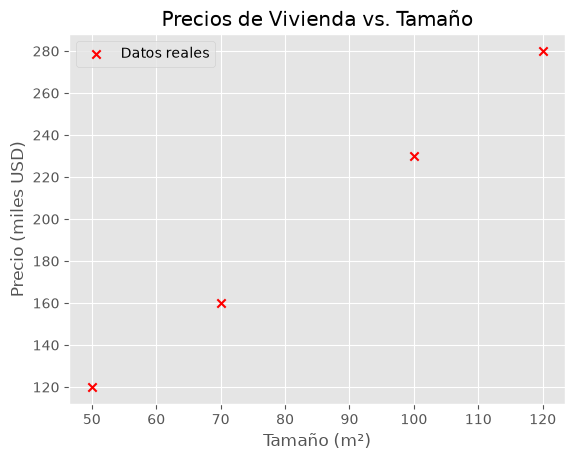

In [3]:
plt.scatter(x_train, y_train, marker='x', c='r', label='Datos reales')
plt.title("Precios de Vivienda vs. Tamaño")
plt.xlabel("Tamaño (m²)")
plt.ylabel("Precio (miles USD)")
plt.legend()
plt.show()

Paso 4: Definir los Parámetros del Modelo ($w$ y $b$)

Asignaremos valores arbitrarios a los parámetros $w$ (peso) y $b$ (sesgo) para observar cómo trazan la recta de predicción inicial.

$w = 2.1$ (Cada metro cuadrado suma $2,100 dólares al precio)

$b = 15.0$ (El precio base sin metros cuadrados es de $15,000 dólares)

In [2]:
w = 2.1
b = 15.0

print(f"Parámetro w: {w}")
print(f"Parámetro b: {b}")

Parámetro w: 2.1
Parámetro b: 15.0


Paso 5: Calcular la Función de Predicción $f_{w,b}(x^{(i)})$

Calculamos todas las predicciones $\hat{y}$con un bucle for.

In [7]:
def compute_model_prediction(x, w, b):
    """
    Calcula la predicción de una regresión lineal
    Args:
      x (ndarray (m,)): Datos de entrada
      w, b (scalar)   : Parámetros del modelo
    Returns
      f_wb (ndarray (m,)): Predicciones f_wb(x)
    """
    # Crear un arreglo vacío del mismo tamaño que x_train (m elementos) de NumPy para guardar las predicciones (y_hat) 
    tmp_f_wb = np.zeros(m)

    # Recorremos cada ejemplo desde i = 0 hasta i = m - 1
    for i in range(m):
        # x_train[i] representa x^(i) en la notación matemática
        # tmp_f_wb[i] almacenará y_hat^(i)
        tmp_f_wb[i] = w * x_train[i] + b

        # Imprimimos lo que sucede en cada iteración
        print(f"Muestra i={i}: x^({i})={x_train[i]} m²  -->  y_hat^({i})={tmp_f_wb[i]} mil USD")

    #Retornamos el arreglo con las predicciones de y    
    return tmp_f_wb

# Calcular las predicciones para todo el dataset
tmp_f_wb = compute_model_prediction(x_train, w, b)

Muestra i=0: x^(0)=50.0 m²  -->  y_hat^(0)=120.0 mil USD
Muestra i=1: x^(1)=70.0 m²  -->  y_hat^(1)=162.0 mil USD
Muestra i=2: x^(2)=100.0 m²  -->  y_hat^(2)=225.0 mil USD
Muestra i=3: x^(3)=120.0 m²  -->  y_hat^(3)=267.0 mil USD


Paso 6: Graficar la Recta de Predicción contra los Datos Reales

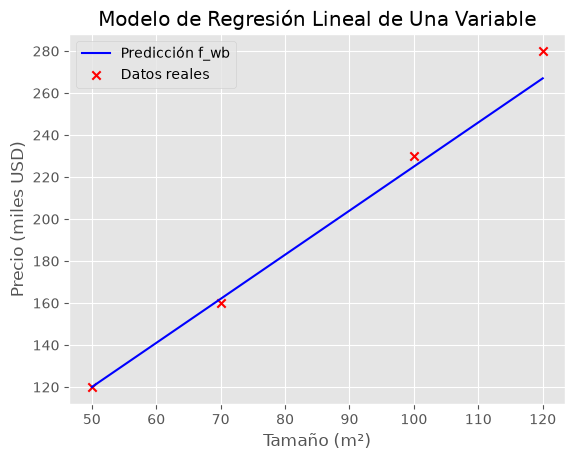

In [8]:
# Graficar la recta de predicción estimada por el modelo
plt.plot(x_train, tmp_f_wb, c='b', label='Predicción f_wb')

# Graficar los puntos reales
plt.scatter(x_train, y_train, marker='x', c='r', label='Datos reales')

plt.title("Modelo de Regresión Lineal de Una Variable")
plt.xlabel("Tamaño (m²)")
plt.ylabel("Precio (miles USD)")
plt.legend()
plt.show()

Paso 7: Hacer una Predicción para un Caso Nuevo

Con la función definida, podemos predecir el valor de una casa que no estaba en nuestro dataset original (por ejemplo, $x = 85\text{ m}^2$).

In [3]:
x_i = 85.0
costo_predicho = w * x_i + b

print(f"Para una casa de {x_i} m², el precio estimado es de ${costo_predicho:.2f} mil USD.")

Para una casa de 85.0 m², el precio estimado es de $193.50 mil USD.


### Función de Costo de error cuadrático

Este mide que tan "equivocado" está el modelo en general evaluando la diferencia entre lo que el modelo predice ($\hat{y}$) y lo que realmente valen las casas ($y$) para todos los $m$ ejemplos de entrenamiento.

La Fórmula Matemática

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)^2$$

O escrita usando la notación $\hat{y}^{(i)}$:

$$J(w,b) = \frac{1}{2m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)^2$$

#### Desglose Paso a Paso de la Fórmula

Error Individual $\left( \hat{y}^{(i)} - y^{(i)} \right)$:
- Es la diferencia (el margen de error) entre lo que predijo la recta para la casa $i$ y su precio real. 
- Ejemplo: Si la casa vale $\$200k$ y predijiste $\$180k$, el error es $-20$.

Error al Cuadrado $\left( \dots \right)^2$:
- Elevar la diferencia al cuadrado cumple dos propósitos esenciales: 
- Elimina los signos negativos: Un error de $-\$20k$ y uno de $+\$20k$ son igual de malos. Al elevar al cuadrado, ambos quedan como $+400$.
- Penaliza severamente los errores grandes: Un error pequeño de $2$ al cuadrado es $4$. Pero un error grande de $10$ al cuadrado es $100$. El modelo "sufrirá" mucho más si comete desaciertos enormes.

Sumatoria $\sum_{i=1}^{m}$:
- Suma todos los errores al cuadrado cometidos desde la primera casa ($i=1$) hasta la última ($i=m$).

División por $m$ ($\frac{1}{m}$):
- Calcula el promedio del error cuadrático. Si no dividiéramos entre $m$, un dataset de 1,000,000 de casas tendría un costo gigantesco solo por tener más datos, aunque el modelo fuera muy preciso.

El factor $\frac{1}{2}$:
- Se añade por conveniencia matemática pura. Más adelante, cuando se aplique el algoritmo de Descenso del Gradiente, se tendrá que calcular la derivada de $J(w,b)$. Al derivar el exponente $2$, este se cancelará exactamente con el $\frac{1}{2}$, simplificando los cálculos en el código.

#### Simplificación Visual: Casos con $b = 0$ y la Parábola de $J(w)$

Para entender de manera intuitiva cómo funciona la Función de Costo sin lidiar con tres dimensiones a la vez, podemos hacer un experimento mental y fijar el valor del sesgo en $b = 0$.Al hacer $b = 0$, la ecuación del modelo se simplifica a:

$$f_w(x) = w \cdot x$$

Esto significa que la recta de predicción siempre obligatoriamente pasará por el origen $(0,0)$, dejando a $w$ (el peso) como el único parámetro ajustable.

La Gráfica de $J(w)$ vs $w$

Si calculamos el valor de la función de costo $J(w)$ probando distintos valores para $w$ (por ejemplo $w = 0$, $w = 0.5$, $w = 1.0$, $w = 2.0$, etc.), al graficar $w$ en el eje horizontal ($X$) y $J(w)$ en el eje vertical ($Y$), obtenemos una curva en forma de U o parábola (conocida en matemáticas como una función convexa).

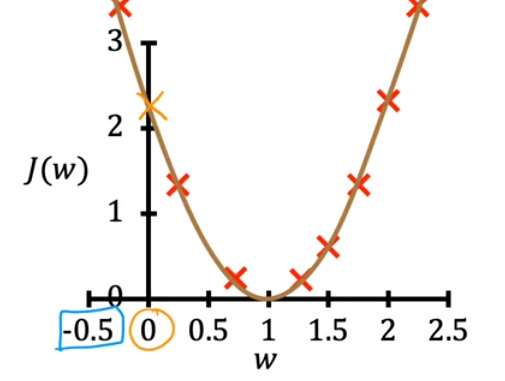

#### Interpretación Intuítiva de la Parábola

Eje Vertical ($Y = J(w)$): Representa la cantidad total de error que comete el modelo.

Punto Mínimo (El fondo de la parábola): Es el valor óptimo de $w$ donde la recta se ajusta mejor a los datos reales. En este punto, el costo $J(w)$ toca o se acerca lo más posible al eje X (es decir, $J(w) \approx 0$).

Puntos Alejados: Conforme te alejas del centro de la parábola (hacia la izquierda o la derecha), la recta se inclina demasiado en la dirección equivocada, haciendo que el error $J(w)$ aumente drásticamente.

### Visualización de la fórmula costo función con w y b

Cuando consideramos tanto el peso ($w$) como el sesgo ($b$), la función de costo $J(w,b)$ deja de ser una curva 2D en forma de parábola y se transforma en una superficie tridimensional (3D).

1. La Gráfica 3D: El "Tazón" (Bowl Shape)Al graficar $w$ en un eje horizontal, $b$ en el otro eje horizontal y el costo $J(w,b)$ en el eje vertical (altura):

Obtendrás una superficie continua con forma de tazón o cuenco (bowl shape).

Interpretación:La altura del tazón representa la cantidad de error $J(w,b)$.

Las partes altas de los bordes representan combinaciones malas de $(w, b)$ donde el modelo comete errores gigantescos.

El fondo del tazón (el punto más bajo posible) representa la combinación óptima de $(w,b)$ donde el error $J(w,b)$ alcanza su mínimo global.

![3D cost function graph](./Resources/3D_costFunction.jpeg)

2. Gráficos de Contorno (Contour Plots)

Visualizar y trabajar con gráficos 3D puede ser incómodo en una pantalla plana. Para solucionar esto, utilizamos gráficos de contorno (contour plots), los cuales cortan el "tazón" 3D con planos horizontales (como un mapa topográfico de una montaña).

Características Clave de los Contornos:

Cada elipse u óvalo representa un nivel de costo $J(w,b)$ constante. Cualquier par de parámetros $(w,b)$ situados sobre la misma línea elíptica tendrán exactamente el mismo valor de error.


El centro de las elipses concentradas ($*$): Es el punto mínimo global de la función de costo. Sitúa la combinación $(w,b)$ que traza la recta perfecta sobre los datos reales.

Cercanía al centro: Entre más te acerques al centro del diagrama de contornos, menor será el error de tu recta de regresión.

![Contour Plot](./Resources/contourPlot.jpg)

3. Implementación en Código de $J(w,b)$

A continuación se muestra la función en Python que calcula el costo $J(w,b)$ considerando ambos parámetros ($w$ y $b$) explícitamente a través del bucle for:

In [2]:
import numpy as np

def compute_cost(x, y, w, b):
    """
    Calcula la función de costo J(w,b) para la Regresión Lineal de una variable.
    
    Parámetros:
      x (ndarray (m,)): Datos de entrada (características / m²)
      y (ndarray (m,)): Valores reales (etiquetas / precios)
      w, b (escalares) : Parámetros del modelo (peso y sesgo)
      
    Devuelve:
      total_cost (float): El costo J(w,b) utilizando Mean Squared Error (MSE)
    """
    m = x.shape[0]
    sum_cost = 0.0
    
    # Recorremos cada ejemplo i desde 0 hasta m-1
    for i in range(m):
        # 1. Calcular la predicción y_hat para la casa i: f_wb(x^(i)) = w*x^(i) + b
        f_wb = w * x[i] + b
        
        # 2. Calcular el error individual al cuadrado: (f_wb - y^(i))^2
        cost_i = (f_wb - y[i]) ** 2
        
        # 3. Sumar el error al acumulador
        sum_cost += cost_i
        
    # 4. Dividir la suma total entre 2*m para obtener el promedio ajustado
    total_cost = (1 / (2 * m)) * sum_cost
    
    return total_cost